# Battlesnake com A*

A* é um algoritmo de busca de caminho que encontra o caminho mais curto entre dois pontos em um grafo. Ele é amplamente utilizado em jogos e aplicações de inteligência artificial para encontrar rotas eficientes. O algoritmo combina a busca em largura com uma heurística que estima o custo restante para chegar ao destino, permitindo que ele explore os caminhos mais promissores primeiro.

## O que é o Battlesnake? 

Segundo o [site oficial](https://docs.battlesnake.com): "_Battlesnake_ é um jogo de programação competitivo onde seu código é o controle".

Cada jogador controla uma cobra que deve se mover pelo tabuleiro, coletando comida e evitando colisões com outras cobras e com as bordas do tabuleiro. O objetivo é sobreviver o maior tempo possível.
Cade cobra é controlada através de uma API.
Nós conhecemos esse evento através do *Campeonato Battlesnake* organizado anualmente pela [Dev. Community Mauá](https://www.instagram.com/devcommunitymaua/).
Eles desenvolveram um _template_ que utilizamos de base para nosso projeto. Todos estão convidados a utilizar o [template](https://github.com/Maua-Dev/battlesnake_fastapi_template) para desenvolver suas cobras e participar do campeonato.

## O que exatamente fizemos?

Neste projeto, fizemos a nossa própria interpretação da API do jogo, utilizando o algoritmo A* para encontrar o caminho mais curto até a comida. O código é dividido em duas partes principais: a <b>_implementação do algoritmo A*_</b> e a <b>_lógica do Battlesnake_</b>.

# 1. _Imports_ necessários

In [ ]:
from typing import List, Optional, Tuple
from random import randint
from math import pow
import numpy as np
import matplotlib.pyplot as plt


# 2. Criando as classes e funções de estrutura do jogo

## Criação de classes para representar as entidades do problema

Nossa modelagem do problema utilizou-se 3 classes principais: 

### a) `Coordinate`
- Representa as coordenadas no tabuleiro

In [ ]:
class Coordinate:
    x: float
    y: float

    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __eq__(self, other):
        return self.x == other.x and self.y == other.y

    def __hash__(self):
        return hash((self.x, self.y))

    @staticmethod
    def from_json(json):
        return Coordinate(json['x'], json['y'])

    def __repr__(self):
        return f"Coordinate: {self.x},{self.y}"

    @staticmethod
    def distance(a, b): 
        return abs(a.x - b.x) + abs(a.y - b.y)

    @staticmethod
    def heuristic_function(a, b):
        return pow(a.x - b.x, 2) + pow(a.y - b.y, 2)

    def move_command(self, move: str):
        if move == "up":
            return Coordinate(self.x, self.y + 1)
        elif move == "down":
            return Coordinate(self.x, self.y - 1)
        elif move == "left":
            return Coordinate(self.x - 1, self.y)
        elif move == "right":
            return Coordinate(self.x + 1, self.y)
        else:
            return Coordinate(self.x, self.y)

### b) `Battlesnake` 
- Representa cada cobra, posição da cabeça, corpo, vida e outras características interessantes para a montagem da estratégia

In [ ]:
class Battlesnake:
    snake_id: str
    name: str
    health: int
    body: List[Coordinate]
    latency: str
    head: Coordinate
    length: int
    shout: str
    squad: str
    color: str


    def __init__(self, snake_id: str, name: str, health: int, body: List[Coordinate], latency: str, head: Coordinate, length: int, shout: str, squad: str, color: str = "#888888"):
        self.snake_id = snake_id
        self.name = name
        self.health = health
        self.body = body
        self.latency = latency
        self.head = head
        self.length = length
        self.shout = shout
        self.squad = squad
        self.color = color

    def __eq__(self, other):
        return self.snake_id == other.snake_id and self.name == other.name and self.health == other.health and self.body == other.body and self.latency == other.latency and self.head == other.head and self.length == other.length and self.shout == other.shout and self.squad == other.squad

    def __repr__(self):
        return f"Snake: {self.name} ({self.snake_id})"

    @staticmethod
    def from_json(json):
        snake_id = json["id"]
        name = json["name"]
        health = json["health"]
        body = [Coordinate.from_json(body) for body in json["body"]]
        latency = json["latency"]
        head = Coordinate.from_json(json["head"])
        length = json["length"]
        shout = json["shout"]
        squad = json.get("squad", "")
        color = json["customizations"].get("color", "#888888")
        return Battlesnake(snake_id, name, health, body, latency, head, length, shout, squad, color)

    def is_inside_snake(self, coordinate: Coordinate):
        for body in self.body:
            if body == coordinate:
                return True
        return False

    # def is_near_head(self, coordinate: Coordinate):
    #     if Coordinate.distance(self.head, coordinate) <= 1:
    #         return True
    #     return False

### c) `Board` 
- Une todas as informações do tabuleiro, como a posição da comida e das cobras.

In [ ]:

class Board:
  height: int
  width: int
  food: List[Coordinate]
  snakes: List[Coordinate]
  hazards: List[Battlesnake]

  def __init__(self, height: int, width: int, food: List[Coordinate], snakes: List[Coordinate], hazards: List[Battlesnake]):
      self.food = food
      self.height = height
      self.width = width
      self.snakes = snakes
      self.hazards = hazards


  def __eq__(self, other):
      return self.height == other.height and self.width == other.width and self.food == other.food and self.snakes == other.snakes and self.hazards == other.hazards

  def __repr__(self):
      return f"Board: {self.width}x{self.height}"

  @staticmethod
  def from_json(json):
      height = json["height"]
      width = json["width"]
      food = [Coordinate.from_json(food) for food in json["food"]]
      snakes = [Battlesnake.from_json(snake) for snake in json["snakes"]]
      hazards = [Coordinate.from_json(hazard) for hazard in json["hazards"]]
      return Board(height, width, food, snakes, hazards)

  @staticmethod
  def navigate_to(start: Coordinate, end: Coordinate) -> str:
      if start.x < end.x:
          return "right"
      elif start.x > end.x:
          return "left"
      elif start.y < end.y:
          return "up"
      elif start.y > end.y:
          return "down"
      else:
          return "up"
    
  def reconstruct_path(self, came_from: dict, current: Coordinate) -> List[Coordinate]:
        total_path = [current]
        while current in came_from:
            current = came_from[current]
            total_path.append(current)
        return total_path[::-1]
      
  def find_path(self, start: Coordinate, end: Coordinate) -> List[Coordinate]:
        
        if end is None:
            return []
        if start == end:
            return [start]
        
        open_set = [start]
        came_from = {}
        g_score = {start: 0}
        f_score = {start: Coordinate.heuristic_function(start, end)}
    
        while open_set:
            current = min(open_set, key=lambda x: f_score.get(x, float('inf')))
    
            if current == end:
                return self.reconstruct_path(came_from, current)
    
            open_set.remove(current)
    
            for neighbor in self.get_valid_neighbors(current):
                tentative_g_score = g_score.get(current, float('inf')) + 1
    
                if tentative_g_score < g_score.get(neighbor, float('inf')):
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g_score
                    f_score[neighbor] = tentative_g_score + Coordinate.heuristic_function(neighbor, end)
                    if neighbor not in open_set:
                        open_set.append(neighbor)
    
        return []

  def where_to_go(self, me: Battlesnake) -> str:

    food = self.get_closest_food(me)
    if food is None:
        return "up"
    
    path = self.find_path(me.head, food)

    print(f"Path: {path}")

    if len(path) == 0:
        return "up"
    next_move = path[1] if len(path) > 1 else path[0]
    move = self.navigate_to(me.head, next_move)

    return move

  def get_closest_food(self, snake: Battlesnake):
      
      if len(self.food) == 0:
        return None

      closest_food = self.food[0]
      for food in self.food:
          if Coordinate.distance(snake.head, food) < Coordinate.distance(snake.head, closest_food):
              closest_food = food
      return closest_food

  def get_valid_neighbors(self, head: Coordinate) -> List[Coordinate]:
      neighbors = []
      for move in ["right", "down", "left", "up"]:
          if not self.is_out_of_bounds(move, head) and not self.is_snake(move, head):
              new_coordinate = head.move_command(move)
              neighbors.append(new_coordinate)
      return neighbors

  def is_snake(self, move: str, head: Coordinate):
      coordinate = head.move_command(move)
      for snake in self.snakes:
          if snake.is_inside_snake(coordinate):
              return snake
      return False

  # def is_hazard(self, move: str, head: Coordinate):
  #     coordinate = head.move_command(move)
  #     for hazard in self.hazards:
  #         if hazard == coordinate:
  #             return True
  #     return False

  # def dodge_snake_body(self, me: Battlesnake, old_move: str):
  #     if  self.can_move(old_move, me):
  #         return old_move

  #     for move in ["up", "down", "left", "right"]:
  #         if self.can_move(move, me):
  #             return move
  #     return old_move

  def is_out_of_bounds(self, move: str, head: Coordinate):
      coordinate = head.move_command(move)
      if coordinate.x < 0 or coordinate.x >= self.width or coordinate.y < 0 or coordinate.y >= self.height:
          return True
      return False

  # def can_move(self, move: str, me: Battlesnake):
  #     head = me.head
  #     snake, move_returned = self.get_near_snake_head(me, move)

  #     if not self.is_out_of_bounds(move, head) and not self.is_snake(move, head) and not self.is_hazard(move, head) and not (snake is not None and snake.length >= me.length):
  #         return True
  #     return False

  # def is_near_snake_head(self, move: str, me: Battlesnake):
  #     snake, move = self.get_near_snake_head(me, move)

  #     if snake is not None:
  #         return True
  #     return False

  # def get_near_snake_head(self, me: Battlesnake, move: str = None) -> Tuple[Optional[Battlesnake], Optional[str]]:
  #     if move is not None:
  #         coordinate = me.head.move_command(move)
  #         for snake in self.snakes:
  #             if snake.is_near_head(coordinate) and snake.snake_id != me.snake_id:
  #                 return snake, move
  #         return None, None

  #     for move in ["up", "down", "left", "right"]:
  #         coordinate = me.head.move_command(move)
  #         for snake in self.snakes:
  #             if snake.is_near_head(coordinate) and snake.snake_id != me.snake_id:
  #                 return snake, move
  #     return None, None


## Exemplo de _request_ transformado nas classes moldadas

### _Request_

In [ ]:
request = {
   "game":{
      "id":"b33d6b4a-a6a7-4f4d-9415-557922943836",
      "ruleset":{
         "name":"standard",
         "version":"v1.2.3",
         "settings":{
            "foodSpawnChance":15,
            "minimumFood":1,
            "hazardDamagePerTurn":0,
            "hazardMap":"",
            "hazardMapAuthor":"",
            "royale":{
               "shrinkEveryNTurns":0
            },
            "squad":{
               "allowBodyCollisions":False,
               "sharedElimination":False,
               "sharedHealth":False,
               "sharedLength":False
            }
         }
      },
      "map":"standard",
      "timeout":500,
      "source":"custom"
   },
   "turn":0,
   "board":{
      "height":11,
      "width":11,
      "snakes":[
         {
            "id":"gs_9pgrtftxXTQJb9VrytSwbtRW",
            "name":"BrancasESoller",
            "latency":"",
            "health":100,
            "body":[
               {
                  "x":9,
                  "y":9
               },
               {
                  "x":9,
                  "y":9
               },
               {
                  "x":9,
                  "y":9
               }
            ],
            "head":{
               "x":9,
               "y":9
            },
            "length":3,
            "shout":"",
            "squad":"",
            "customizations":{
               "color":"#ffde21",
               "head":"ski",
               "tail":"weight"
            }
         },
      ],
      "food":[
         {
            "x":8,
            "y":10
         }
      ],
      "hazards":[
      ]
   },
   "you":{
      "id":"gs_9pgrtftxXTQJb9VrytSwbtRW",
      "name":"BrancasESoller",
      "latency":"",
      "health":100,
      "body":[
         {
            "x":9,
            "y":9
         },
         {
            "x":10,
            "y":9
         },
      ],
      "head":{
         "x":9,
         "y":9
      },
      "length":2,
      "shout":"",
      "squad":"",
      "customizations":{
         "color":"#ffde21",
         "head":"ski",
         "tail":"weight"
      }
   }
}

### Transformação do JSON

In [ ]:
board = Board.from_json(request["board"])
me = Battlesnake.from_json(request["you"])

## Visualizando o tabuleiro de forma gráfica

Função que desenha o tabuleiro, cobras e futuramente o caminho encontrado pelo A*:

In [ ]:
def draw_path(board: Board, path: List[Coordinate], me: Battlesnake):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, board.width)
    ax.set_ylim(0, board.height)
    ax.set_xticks(np.arange(0, board.width + 1, 1))
    ax.set_yticks(np.arange(0, board.height + 1, 1))
    ax.grid(which='both', color='gray', linestyle='-', linewidth=0.5)

    for food in board.food:
        ax.add_patch(plt.Circle((food.x + 0.5, food.y + 0.5), 0.2, color='purple', label='Food'))

    for snake in board.snakes:
        for body in snake.body:

            if snake.snake_id == me.snake_id:
                ax.add_patch(plt.Rectangle((body.x, body.y), 1, 1, color='blue', label='Me'))
            else:
                ax.add_patch(plt.Rectangle((body.x, body.y), 1, 1, color='red', label='Enemy'))

            if body == snake.head:
                ax.add_patch(plt.Circle((body.x + 0.5, body.y + 0.5), 0.3, color='yellow', label='Head'))
                

        # if snake.snake_id == me.snake_id:
        #     color = 'blue'
        # else:
        #     color = 'red'
        # for body in snake.body:
        #     ax.add_patch(plt.Rectangle((body.x, body.y), 1, 1, color=color))
        #     if body == snake.head:
        #         ax.add_patch(plt.Circle((body.x + 0.5, body.y + 0.5), 0.3, color='yellow', label='Head'))

    for coordinate in path:
        ax.add_patch(plt.Circle((coordinate.x + 0.5, coordinate.y + 0.5), 0.1, color='blue'))
        if coordinate != path[-1]:
            next_coordinate = path[path.index(coordinate) + 1]
            ax.plot([coordinate.x + 0.5, next_coordinate.x + 0.5], [coordinate.y + 0.5, next_coordinate.y + 0.5], color='blue', linewidth=2)

    ax.legend(loc='upper right')

    plt.show()

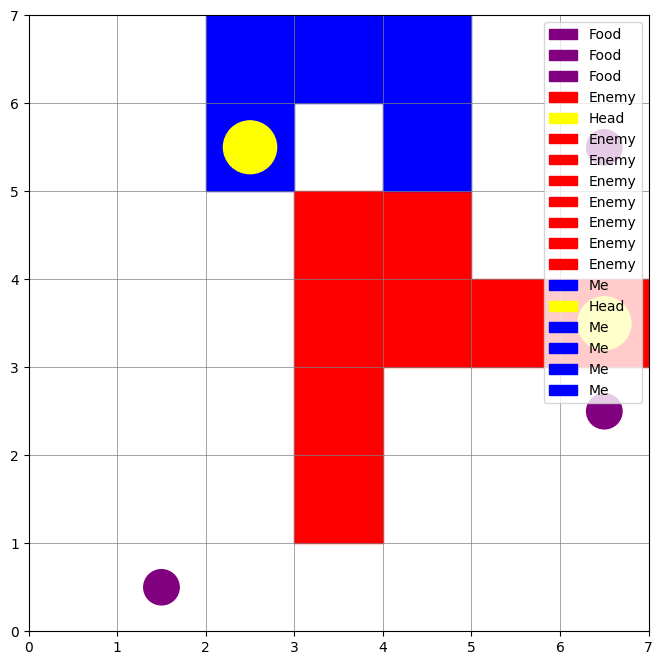

In [ ]:
draw_path(board,[], me)

Exibindo 

In [ ]:
board.where_to_go(me)

Path: []


'up'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def draw_board(board: Board, me: Battlesnake):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, board.width)
    ax.set_ylim(0, board.height)
    ax.set_xticks(np.arange(0, board.width + 1, 1))
    ax.set_yticks(np.arange(0, board.height + 1, 1))
    ax.grid(which='both', color='gray', linestyle='-', linewidth=0.5)

    for food in board.food:
        ax.add_patch(plt.Circle((food.x + 0.5, food.y + 0.5), 0.2, color='red'))

    for snake in board.snakes:
        if snake.snake_id == me.snake_id:
            color = 'blue'
        else:
            color = 'green'
        for body in snake.body:
            ax.add_patch(plt.Rectangle((body.x, body.y), 1, 1, color=color))
            if body == snake.head:
                ax.add_patch(plt.Circle((body.x + 0.5, body.y + 0.5), 0.3, color='yellow'))

    ax.add_patch(plt.Circle((me.head.x + 0.5, me.head.y + 0.5), 0.3, color='yellow'))
    
    plt.show()

In [ ]:
def draw_path(board: Board, path: List[Coordinate], me: Battlesnake):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, board.width)
    ax.set_ylim(0, board.height)
    ax.set_xticks(np.arange(0, board.width + 1, 1))
    ax.set_yticks(np.arange(0, board.height + 1, 1))
    ax.grid(which='both', color='gray', linestyle='-', linewidth=0.5)

    for food in board.food:
        ax.add_patch(plt.Circle((food.x + 0.5, food.y + 0.5), 0.2, color='red'))

    for snake in board.snakes:
        if snake.snake_id == me.snake_id:
            color = 'blue'
        else:
            color = snake.color
        for body in snake.body:
            ax.add_patch(plt.Rectangle((body.x, body.y), 1, 1, color=color))
            if body == snake.head:
                ax.add_patch(plt.Circle((body.x + 0.5, body.y + 0.5), 0.3, color='yellow'))

    for coordinate in path:
        ax.add_patch(plt.Circle((coordinate.x + 0.5, coordinate.y + 0.5), 0.1, color='blue'))
        if coordinate != path[-1]:
            next_coordinate = path[path.index(coordinate) + 1]
            ax.plot([coordinate.x + 0.5, next_coordinate.x + 0.5], [coordinate.y + 0.5, next_coordinate.y + 0.5], color='blue', linewidth=2)

    plt.show()

In [ ]:
request = {
   'game':{
      'id':'f4335f0d-bcc8-4c52-ac78-ba36ec5aaa12',
      'ruleset':{
         'name':'standard',
         'version':'v1.2.3',
         'settings':{
            'foodSpawnChance':15,
            'minimumFood':1,
            'hazardDamagePerTurn':0,
            'hazardMap':'',
            'hazardMapAuthor':'',
            'royale':{
               'shrinkEveryNTurns':0
            },
            'squad':{
               'allowBodyCollisions':False,
               'sharedElimination':False,
               'sharedHealth':False,
               'sharedLength':False
            }
         }
      },
      'map':'standard',
      'timeout':500,
      'source':'custom'
   },
   'turn':8,
   'board':{
      'height':11,
      'width':11,
      'snakes':[
         
         {
            'id':'gs_4Xr69fDb83XwfpY6WM4YwkjK',
            'name':'ssssoller',
            'latency':'32',
            'health':94,
            'body':[
               {
                  'x':7,
                  'y':5
               },
               {
                  'x':6,
                  'y':5
               },
               {
                  'x':6,
                  'y':6
               },
               {
                  'x':7,
                  'y':6
               }
            ],
            'head':{
               'x':7,
               'y':5
            },
            'length':4,
            'shout':'Salve, cria!',
            'squad':'',
            'customizations':{
               'color':'#ff5f1f',
               'head':'chicken',
               'tail':'flytrap'
            }
         },
         
      ],
      'food':[
         {
            'x':1,
            'y':1
         },
         
      ],
      'hazards':[
         
      ]
   },
   'you':{
      'id':'gs_4Xr69fDb83XwfpY6WM4YwkjK',
      'name':'ssssoller',
      'latency':'32',
      'health':94,
      'body':[
         {
            'x':7,
            'y':5
         },
         {
            'x':6,
            'y':5
         },
         {
            'x':6,
            'y':6
         },
         {
            'x':7,
            'y':6
         }
      ],
      'head':{
         'x':7,
         'y':5
      },
      'length':4,
      'shout':'Salve, cria!',
      'squad':'',
      'customizations':{
         'color':'#ff5f1f',
         'head':'chicken',
         'tail':'flytrap'
      }
   }
}

In [ ]:
board = Board.from_json(request["board"])
me = Battlesnake.from_json(request["you"])

In [ ]:
# draw_board(board, me)

In [ ]:
board.where_to_go(me)

Path: [Coordinate: 7,5, Coordinate: 7,4, Coordinate: 6,4, Coordinate: 5,4, Coordinate: 4,4, Coordinate: 4,3, Coordinate: 3,3, Coordinate: 3,2, Coordinate: 2,2, Coordinate: 2,1, Coordinate: 1,1]


'down'